# KITTI 데이터셋으로 YOLO 객체 탐지하기

## 전체 과정

1. KITTI 데이터셋 준비
2. KITTI 데이터 구조 확인
3. Train / Validation 분할
4. KITTI 라벨 형식 이해
5. YOLOv1 Target 생성
6. Dataset / DataLoader 구성
7. YOLOv1 모델 구현
8. YOLOv1 Loss 구현
9. 모델 학습 및 Validation
10. Checkpoint 저장 및 학습 재개
11. Best 모델 확인 및 Loss 그래프
12. 실제 객체 탐지 결과 확인

## 1. KITTI 데이터셋 다운로드 

https://www.cvlibs.net/datasets/kitti/eval_object.php?obj_benchmark

위 링크에서 다음 두 파일을 다운로드 합니다.
* left color images of object data set -> RGB 이미지
* training labels of object data set -> 객체 클래스와 bounding box 정보

압축 해제한 파일을 이 노트북과 같은 프로젝트 폴더에 다음과 같은 형식으로 넣어둡니다.

```text
kitti_yolo/
├── kitti_yolo.ipynb
├── data_object_image_2.zip
└── data_object_label_2.zip 
```


먼저 현재 코드가 실행되고 있는 **작업 폴더(Working Directory)** 를 확인합니다.

작업 폴더는 파일이나 폴더를 찾을 때 기본 경로로 사용되므로, 이후 KITTI 데이터셋의 이미지와 라벨 파일을 불러오기 전에 확인하는 것이 좋습니다.

- `Path.cwd()` : 현재 작업 폴더의 경로를 가져옵니다.
- `iterdir()` : 해당 폴더 안에 있는 파일과 폴더를 확인합니다.
- `p.name` : 파일 또는 폴더의 이름을 가져옵니다.

아래 코드를 실행하여 현재 작업 위치와 프로젝트 폴더 내부의 파일 목록을 확인합니다.

In [ ]:
import os 
from pathlib import Path
PROJECT_DIR = Path.cwd()

print(f"Current working directory: {PROJECT_DIR}")
print("Contents of the project directory:")
for p in PROJECT_DIR.iterdir():
    print(" -", p.name)

Current working directory: /Users/kimeunha/study/kitti_yolo
Contents of the project directory:
 - checkpoints2
 - .DS_Store
 - YOLO_Object_Detection.ipynb
 - checkpoints
 - README.md
 - data_object_label_2.zip
 - .git
 - data_object_image_2.zip
 - kitti_raw
 - pretrained


## 2. 필요한 라이브러리 설치

YOLO 모델을 실행하고 KITTI 데이터를 처리하기 위해 필요한 라이브러리를 설치합니다.

- `torch` : 딥러닝 모델을 실행하기 위한 PyTorch 라이브러리입니다.
- `torchvision` : 이미지 처리 및 컴퓨터 비전 기능을 제공합니다.
- `pillow` : 이미지 파일을 불러오고 처리할 때 사용합니다.
- `matplotlib` : 이미지와 탐지 결과를 화면에 출력할 때 사용합니다.

아래 코드를 실행하여 필요한 라이브러리를 설치합니다.

In [58]:
%pip install torch torchvision pillow matplotlib

You should consider upgrading via the '/Users/kimeunha/data/Databases/KITTI/Odometry/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


## 3. KITTI 데이터셋 압축 해제

이제 다운로드한 **KITTI 이미지와 라벨 데이터**의 압축을 해제합니다.

KITTI 데이터셋은 이미지 파일과 객체 정보를 담고 있는 라벨 파일이 각각 ZIP 파일로 제공됩니다. 이를 프로젝트 폴더의 `kitti_raw` 폴더에 압축 해제합니다.

### 데이터 구성

- `data_object_image_2.zip` : KITTI 차량용 카메라 이미지
- `data_object_label_2.zip` : 각 이미지의 객체 탐지 라벨
- `kitti_raw` : 압축을 해제한 데이터를 저장할 폴더

압축 해제 후에는 다음과 같은 구조가 됩니다.

```text
kitti_raw/
└── training/
    ├── image_2/    # 이미지
    └── label_2/    # 객체 라벨

In [59]:
from pathlib import Path
import zipfile

image_zip = PROJECT_DIR / "data_object_image_2.zip"
label_zip = PROJECT_DIR / "data_object_label_2.zip"

raw_dir = PROJECT_DIR / "kitti_raw"

# 이미 압축이 풀려 있는지 확인
image_dir = raw_dir / "training" / "image_2"
label_dir = raw_dir / "training" / "label_2"

if image_dir.exists() and label_dir.exists():
    print("KITTI 데이터가 이미 압축 해제되어 있음")
    print("저장 위치:", raw_dir)

else:
    # ZIP 파일 존재 여부 확인
    if not image_zip.exists():
        raise FileNotFoundError(f"이미지 ZIP 파일을 찾을 수 없음: {image_zip}")

    if not label_zip.exists():
        raise FileNotFoundError(f"라벨 ZIP 파일을 찾을 수 없음: {label_zip}")

    # 데이터 폴더 생성
    raw_dir.mkdir(exist_ok=True)

    # 이미지 압축 해제
    with zipfile.ZipFile(image_zip, "r") as z:
        z.extractall(raw_dir)

    # 라벨 압축 해제
    with zipfile.ZipFile(label_zip, "r") as z:
        z.extractall(raw_dir)

    print("KITTI 데이터 압축 해제 완료")
    print("저장 위치:", raw_dir)

KITTI 데이터가 이미 압축 해제되어 있음
저장 위치: /Users/kimeunha/study/kitti_yolo/kitti_raw


## 4. 압축 해제된 데이터 구조 확인

압축 해제가 정상적으로 완료되었는지 확인하기 위해 `kitti_raw` 폴더 안의 **하위 폴더 구조**를 확인합니다.

`rglob("*")`을 사용하면 `kitti_raw` 폴더 내부의 모든 파일과 폴더를 하위 폴더까지 탐색할 수 있습니다.

아래 코드는 그중 **폴더만 골라 경로를 출력**합니다.

In [37]:
for path in raw_dir.rglob("*"):
    if path.is_dir():
        print("DIR :", path)

DIR : /Users/kimeunha/study/kitti_yolo/kitti_raw/training
DIR : /Users/kimeunha/study/kitti_yolo/kitti_raw/testing
DIR : /Users/kimeunha/study/kitti_yolo/kitti_raw/training/image_2
DIR : /Users/kimeunha/study/kitti_yolo/kitti_raw/training/label_2
DIR : /Users/kimeunha/study/kitti_yolo/kitti_raw/testing/image_2


## 5. KITTI 이미지와 라벨 확인

이제 KITTI 데이터셋의 **이미지와 라벨 파일이 제대로 준비되었는지 확인합니다.**

- `image_2` : KITTI의 카메라 이미지가 저장된 폴더입니다.
- `label_2` : 각 이미지에 대한 객체의 종류와 위치 정보가 저장된 폴더입니다.
- 이미지와 라벨은 **같은 파일 이름을 기준으로 서로 대응**합니다. 예를 들어 `000001.png`에 대한 라벨은 `000001.txt`입니다.

먼저 두 폴더가 실제로 존재하는지 확인한 후, 이미지와 라벨의 개수 및 파일 이름 일부를 출력합니다.

In [128]:
image_dir = raw_dir / "training" / "image_2"
label_dir = raw_dir / "training" / "label_2"

if not image_dir.exists():
    raise FileNotFoundError(f"이미지 폴더를 찾을 수 없음: {image_dir}")

if not label_dir.exists():
    raise FileNotFoundError(f"라벨 폴더를 찾을 수 없음: {label_dir}")

images = sorted(image_dir.glob("*.png"))
labels = sorted(label_dir.glob("*.txt"))

print("이미지 개수 :", len(images))
print("라벨 개수  :", len(labels))

print("\n이미지 예시:")
for p in images[:5]:
    print(p.name)

print("\n라벨 예시:")
for p in labels[:5]:
    print(p.name)

이미지 개수 : 7481
라벨 개수  : 7481

이미지 예시:
000000.png
000001.png
000002.png
000003.png
000004.png

라벨 예시:
000000.txt
000001.txt
000002.txt
000003.txt
000004.txt


## 6. KITTI 라벨 형식 이해하기

KITTI 라벨의 한 줄은 다음과 같은 형식으로 구성됩니다.

```text
Car 0.00 0 -1.57 599.41 156.40 629.75 189.25 ...
```

여기서 객체 탐지에 필요한 값은 다음과 같습니다.

- 첫 번째 값: 클래스 이름
- `parts[4:8]`: 2D Bounding Box 좌표
- `xmin, ymin, xmax, ymax`: 객체의 왼쪽 위와 오른쪽 아래 좌표

즉, KITTI Bounding Box는 다음과 같은 형식입니다.

```text
xmin ymin xmax ymax
```

반면 YOLO에서는 Bounding Box를 다음과 같은 형식으로 표현합니다.

```text
x_center y_center width height
```

따라서 KITTI의 Bounding Box를 YOLO에서 사용할 수 있도록 다음과 같은 과정을 수행합니다.

1. `xmin, ymin, xmax, ymax`를 `x_center, y_center, width, height`로 변환합니다.
2. 이미지 크기를 기준으로 좌표를 0~1 범위로 정규화합니다.
3. 객체의 중심점이 위치한 Grid Cell을 계산합니다.
4. 해당 Grid Cell에 Bounding Box와 클래스 정보를 저장합니다.

이번 실습에서는 **7 × 7 Grid를 사용하는 YOLOv1 방식**으로 Target을 구성합니다.

## 7. 객체 클래스 정의

KITTI 라벨에 포함된 객체의 종류를 숫자로 변환하기 위해 **클래스 번호(Class ID)** 를 정의합니다.

이번 실습에서는 다음 3개의 클래스를 사용합니다.

- `Car` → `0`
- `Pedestrian` → `1`
- `Cyclist` → `2`

YOLO 모델은 클래스 이름 자체가 아니라 숫자로 된 클래스 ID를 사용하기 때문에, 이후 라벨을 변환할 때 이 매핑을 사용합니다.

`NUM_CLASSES`는 전체 클래스의 개수를 저장하며, 여기서는 총 **3개**입니다.

In [124]:
CLASS_NAMES = {
    "Car": 0,
    "Pedestrian": 1,
    "Cyclist": 2,
}

NUM_CLASSES = len(CLASS_NAMES)

## 8. 학습 데이터와 검증 데이터 분할

모델을 학습하기 위해 전체 이미지를 **학습 데이터(Train)** 와 **검증 데이터(Validation)** 로 나눕니다.

이번 실습에서는 전체 데이터의 **80%를 학습 데이터**, **20%를 검증 데이터**로 사용합니다.

- **Train 데이터**: YOLO 모델의 학습에 사용합니다.
- **Validation 데이터**: 학습된 모델의 성능을 확인하는 데 사용합니다.

`random.shuffle()`을 사용하여 이미지 순서를 무작위로 섞은 후 데이터를 분할합니다.

또한 `random.seed(42)`를 설정하여 코드를 다시 실행하더라도 **항상 같은 순서로 데이터가 섞이도록** 합니다. 이를 통해 매번 동일한 데이터 분할 결과를 얻을 수 있습니다.

In [125]:
import random

# 재현 가능한 데이터 분할
random.seed(42)

all_images = sorted(image_dir.glob("*.png"))

random.shuffle(all_images)

split_index = int(len(all_images) * 0.8)

train_images = all_images[:split_index]
val_images = all_images[split_index:]

print("Train 이미지:", len(train_images))
print("Validation 이미지:", len(val_images))

Train 이미지: 5984
Validation 이미지: 1497


## 9. YOLOv1 설정

YOLOv1은 이미지를 **S × S 크기의 Grid Cell**로 나누고, 각 Grid Cell에서 객체의 위치와 클래스를 예측합니다.

이번 실습에서는 다음과 같이 설정합니다.

- `S = 7` : 이미지를 7 × 7 Grid로 나눕니다.
- `B = 2` : 각 Grid Cell에서 2개의 Bounding Box를 예측합니다.
- `C = 3` : `Car`, `Pedestrian`, `Cyclist` 총 3개의 클래스를 사용합니다.

각 Bounding Box는 다음 5개의 값을 예측합니다.

```text
x, y, width, height, confidence
```

따라서 각 Grid Cell의 출력 크기는 다음과 같이 계산됩니다.

```text
B × 5 + C
= 2 × 5 + 3
= 13
```

전체 출력 크기는 다음과 같습니다.

```text
7 × 7 × 13
```

즉, YOLOv1은 이미지 하나를 입력받아 **7 × 7개의 Grid Cell 각각에 13개의 값을 예측**합니다.

In [ ]:
# YOLOv1 설정
S = 7
B = 2
NUM_CLASSES = len(CLASS_NAMES)

print("Grid size (S):", S)
print("Bounding boxes per cell (B):", B)
print("Number of classes (C):", NUM_CLASSES)

print("Output size:", S, "×", S, "×", (B * 5 + NUM_CLASSES))

Grid size (S): 7
Bounding boxes per cell (B): 2
Number of classes (C): 3
Output size: 7 × 7 × 13


## 10. KITTI 라벨을 YOLOv1 Target으로 변환

앞에서 확인한 것처럼 KITTI와 YOLOv1은 **Bounding Box를 표현하는 방식이 다릅니다.**

따라서 KITTI 라벨을 YOLOv1 모델이 학습할 수 있는 **Target 형태로 변환**해야 합니다.

이 함수에서는 다음 과정을 수행합니다.

1. 이미지의 크기를 확인합니다.
2. KITTI 라벨에서 객체의 클래스와 Bounding Box 좌표를 가져옵니다.
3. Bounding Box를 `x_center, y_center, width, height` 형식으로 변환합니다.
4. 좌표를 이미지 크기를 기준으로 **0~1 범위로 정규화**합니다.
5. 객체 중심이 포함된 `7 × 7` Grid Cell을 찾습니다.
6. 해당 Grid Cell에 Bounding Box와 클래스 정보를 저장합니다.

### Target의 구조

각 Grid Cell에는 다음과 같은 값이 저장됩니다.

```text
[x, y, w, h, conf, x, y, w, h, conf, class_0, class_1, class_2]
```

여기서 `x`, `y`는 **Grid Cell 내부에서의 상대적인 중심 좌표**이며, `w`, `h`는 이미지 전체를 기준으로 정규화된 Bounding Box의 너비와 높이입니다.

또한 `Van`과 `Truck`은 이번 실습에서 `Car`로 통합하고, `CLASS_NAMES`에 포함되지 않은 객체는 학습에서 제외합니다.

한 Grid Cell에는 하나의 객체만 할당하도록 구성합니다.

In [132]:
import torch


def kitti_to_yolov1_target(
    label_path,
    image_path,
    S=7,
    B=2,
    C=3
):
    """
    KITTI 원본 라벨을 YOLOv1 target으로 변환합니다.

    Target shape:
        [S, S, 5 + C]

    각 Grid cell:
        [x, y, w, h, confidence] × B
        + class probabilities
    """

    # Target 초기화
    target = torch.zeros(
        S,
        S,
        5 * B + C
    )

    # 이미지 크기 확인
    with Image.open(image_path) as img:
        img_width, img_height = img.size

    with open(label_path, "r") as f:

        for line in f:
            parts = line.strip().split()

            if len(parts) < 8:
                continue

            class_name = parts[0]

            # Van, Truck을 Car로 통합
            if class_name in ["Van", "Truck"]:
                class_name = "Car"

            # 나머지 class 제외
            if class_name not in CLASS_NAMES:
                continue

            class_id = CLASS_NAMES[class_name]

            # KITTI Bounding Box
            xmin = float(parts[4])
            ymin = float(parts[5])
            xmax = float(parts[6])
            ymax = float(parts[7])

            
            # Bounding Box 계산
            x_center = (xmin + xmax) / 2
            y_center = (ymin + ymax) / 2

            width = xmax - xmin
            height = ymax - ymin

            # 0~1 정규화
            x_center /= img_width
            y_center /= img_height

            width /= img_width
            height /= img_height

            # 객체 중심이 위치한 Grid
            grid_x = min(int(x_center * S), S - 1)
            grid_y = min(int(y_center * S), S - 1)

            # Grid 내부 상대 좌표
            x_cell = x_center * S - grid_x
            y_cell = y_center * S - grid_y

            # 한 Grid cell에 이미 객체가 있으면 제외
            if target[grid_y, grid_x, 4] == 1:
                continue

            # 첫 번째 Bounding Box에 저장
            target[grid_y, grid_x, 0] = x_cell
            target[grid_y, grid_x, 1] = y_cell
            target[grid_y, grid_x, 2] = width
            target[grid_y, grid_x, 3] = height
            target[grid_y, grid_x, 4] = 1

            # Class
            target[
                grid_y,
                grid_x,
                5 * B + class_id
            ] = 1

    return target

## 11. KITTI Dataset 클래스 정의

앞에서 만든 KITTI 이미지와 Target을 **PyTorch에서 학습에 사용할 수 있는 Dataset 형태**로 구성합니다.

`KITTIDataset`은 이미지와 해당 이미지의 라벨을 하나씩 불러오고, 학습에 필요한 전처리를 적용한 후 **이미지와 Target을 함께 반환**합니다.

주요 과정은 다음과 같습니다.

1. KITTI 이미지와 라벨 파일을 불러옵니다.
2. KITTI 라벨을 YOLOv1 Target으로 변환합니다.
3. 학습 데이터인 경우 이미지를 좌우 반전할 수 있습니다.
4. 이미지를 `448 × 448` 크기로 변환합니다.
5. 이미지와 Target을 함께 반환합니다.

### Horizontal Flip

학습 데이터에는 일정한 확률로 이미지를 좌우 반전합니다.

이미지만 반전하면 Bounding Box의 위치가 원본과 달라지기 때문에 **이미지와 함께 Target의 위치도 좌우로 반전**해야 합니다.

이를 통해 같은 객체를 다양한 방향과 위치에서 학습할 수 있어 데이터 증강 효과를 얻을 수 있습니다.

In [133]:
from torch.utils.data import Dataset

class KITTIDataset(Dataset):
    def __init__(
        self,
        image_files,
        label_dir,
        image_size=448,
        train=False,
        flip_probability=0.5
    ):
        self.image_files = image_files
        self.label_dir = Path(label_dir)
        self.train = train
        self.flip_probability = flip_probability

        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.15,
                hue=0.05
            ),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_path = self.image_files[idx]

        image = Image.open(
            image_path
        ).convert("RGB")

        # 원본 KITTI label을 먼저 target으로 변환합니다.
        label_path = (
            self.label_dir /
            f"{image_path.stem}.txt"
        )

        target = kitti_to_yolov1_target(
            label_path,
            image_path,
            S=S,
            B=B,
            C=NUM_CLASSES
        )

        # 학습 데이터에는 Horizontal Flip을 적용합니다.
        # 이미지와 bounding box가 함께 뒤집히도록 target도 변환합니다.
        if self.train and random.random() < self.flip_probability:
            image = image.transpose(
                Image.Transpose.FLIP_LEFT_RIGHT
            )

            flipped_target = torch.zeros_like(target)

            for grid_y in range(S):
                for grid_x in range(S):

                    if target[grid_y, grid_x, 4] <= 0:
                        continue

                    # 기존 grid cell의 중심 x를 전체 이미지 기준으로 복원
                    x_center = (
                        grid_x + target[grid_y, grid_x, 0]
                    ) / S

                    # 좌우 반전
                    flipped_x_center = 1.0 - x_center

                    new_grid_x = min(
                        int(flipped_x_center * S),
                        S - 1
                    )

                    new_x_cell = (
                        flipped_x_center * S
                        - new_grid_x
                    )

                    # 같은 cell에 이미 객체가 있다면
                    # 해당 객체는 유지합니다.
                    if flipped_target[
                        grid_y, new_grid_x, 4
                    ] > 0:
                        continue

                    flipped_target[
                        grid_y, new_grid_x, 0
                    ] = new_x_cell

                    flipped_target[
                        grid_y, new_grid_x, 1:5
                    ] = target[
                        grid_y, grid_x, 1:5
                    ]

                    flipped_target[
                        grid_y, new_grid_x, 5 * B:
                    ] = target[
                        grid_y, grid_x, 5 * B:
                    ]

            target = flipped_target

        image = self.transform(image)

        return image, target


## 12. Train / Validation Dataset 생성

앞에서 정의한 `KITTIDataset`을 이용하여 **학습 데이터셋(Train Dataset)** 과 **검증 데이터셋(Validation Dataset)** 을 생성합니다.

- `train=True`로 설정하면 학습 데이터에 **Horizontal Flip** 등의 데이터 증강이 적용됩니다.
- 검증 데이터는 데이터 증강을 적용하지 않습니다.

마지막으로 각 Dataset에 포함된 이미지의 개수를 출력하여 데이터가 정상적으로 구성되었는지 확인합니다.

In [134]:
train_dataset = KITTIDataset(
    image_files=train_images,
    label_dir=label_dir,
    train=True
)

val_dataset = KITTIDataset(
    image_files=val_images,
    label_dir=label_dir
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))

Train dataset: 5984
Validation dataset: 1497


## 13. DataLoader 생성

Dataset을 만든 후에는 `DataLoader`를 사용하여 데이터를 **배치 단위로 모델에 전달**할 수 있도록 구성합니다.

`BATCH_SIZE = 16`으로 설정했기 때문에 한 번에 **16개의 이미지와 Target**을 불러옵니다.

- `shuffle=True` : 학습 데이터를 매 epoch마다 무작위로 섞습니다.
- `shuffle=False` : 검증 데이터의 순서를 섞지 않습니다.
- `num_workers=0` : 데이터를 불러오는 작업을 메인 프로세스에서 수행합니다.

마지막으로 첫 번째 배치를 불러와 이미지와 Target의 크기를 확인합니다.

예상되는 크기는 다음과 같습니다.

```text
Images shape  : [16, 3, 448, 448]
Targets shape : [16, 7, 7, 13]
```

여기서 `16`은 배치 크기, `3`은 RGB 채널, `448 × 448`은 이미지 크기를 의미합니다.

In [135]:
from torch.utils.data import DataLoader


BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

images, targets = next(iter(train_loader))

print("Images shape :", images.shape)
print("Targets shape:", targets.shape)

Images shape : torch.Size([16, 3, 448, 448])
Targets shape: torch.Size([16, 7, 7, 13])


## 14. YOLOv1 모델 정의

이제 이미지에서 객체의 위치와 종류를 예측하는 **YOLOv1 모델**을 정의합니다.

모델은 크게 두 부분으로 구성됩니다.

- **Convolution Layers**: 이미지에서 객체의 특징을 추출합니다.
- **Fully Connected Layers**: 추출한 특징을 이용하여 각 Grid Cell의 Bounding Box와 클래스 정보를 예측합니다.

입력 이미지는 `448 × 448` 크기이며, 여러 개의 Convolution과 Pooling 층을 거치면서 특징을 추출합니다. 마지막에는 `7 × 7` Grid에 대한 예측값을 출력합니다.

### 출력 구조

이번 실습에서는 다음과 같이 설정합니다.

- `S = 7` : 7 × 7 Grid
- `B = 2` : 각 Grid Cell에서 2개의 Bounding Box를 예측
- `C = 3` : `Car`, `Pedestrian`, `Cyclist` 3개 클래스

따라서 각 Grid Cell에서는

```text
5 × B + C
= 5 × 2 + 3
= 13
```

개의 값을 출력합니다.

각 Bounding Box는 다음 5개의 값을 가집니다.

```text
x, y, width, height, confidence
```

따라서 최종 모델 출력의 크기는 다음과 같습니다.

```text
[batch_size, 7, 7, 13]
```

즉, 하나의 이미지에 대해 **7 × 7개의 Grid Cell 각각에서 13개의 값을 예측**합니다.

마지막으로 `reshape()`을 사용하여 Fully Connected Layer의 출력을 `7 × 7 × 13` 형태로 변환합니다.

In [69]:
import torch
import torch.nn as nn


class YOLOv1(nn.Module):

    def __init__(self, num_classes=3, S=7, B=2):
        super().__init__()

        self.S = S
        self.B = B
        self.num_classes = num_classes

        # -------------------------
        # 1. Convolution Layers
        # -------------------------

        self.backbone = nn.Sequential(

            # 448x448
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
            nn.LeakyReLU(0.1),

            # 224x224 -> 112x112
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 112x112
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1),

            # 112x112 -> 56x56
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 56x56
            nn.Conv2d(192, 128, kernel_size=1),
            nn.LeakyReLU(0.1),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1),

            nn.Conv2d(256, 256, kernel_size=1),
            nn.LeakyReLU(0.1),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1),

            # 56x56 -> 28x28
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 반복되는 1x1 -> 3x3 구조
            nn.Conv2d(512, 256, kernel_size=1),
            nn.LeakyReLU(0.1),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1),

            nn.Conv2d(512, 256, kernel_size=1),
            nn.LeakyReLU(0.1),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1),

            nn.Conv2d(512, 256, kernel_size=1),
            nn.LeakyReLU(0.1),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1),

            nn.Conv2d(512, 256, kernel_size=1),
            nn.LeakyReLU(0.1),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1),

            # 28x28
            nn.Conv2d(512, 512, kernel_size=1),
            nn.LeakyReLU(0.1),

            nn.Conv2d(512, 1024, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1),

            # 28x28 -> 14x14
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(1024, 512, kernel_size=1),
            nn.LeakyReLU(0.1),

            nn.Conv2d(512, 1024, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1),

            nn.Conv2d(1024, 512, kernel_size=1),
            nn.LeakyReLU(0.1),

            nn.Conv2d(512, 1024, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1),

            nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1),

            nn.Conv2d(1024, 1024, kernel_size=3,
                      stride=2, padding=1),
            nn.LeakyReLU(0.1),

            # 14x14 -> 7x7
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1),

            nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1),
        )

        # -------------------------
        # 2. Fully Connected Layers
        # -------------------------

        self.fc = nn.Sequential(

            nn.Flatten(),

            nn.Linear(1024 * 7 * 7, 4096),
            nn.LeakyReLU(0.1),

            nn.Linear(
                4096,
                S * S * (B * 5 + num_classes)
            )
        )
        
        self._initialize_weights()

    def _initialize_weights(self):
        # YOLOv1을 처음부터 학습하므로
        # Conv/Linear layer를 Kaiming 방식으로 초기화합니다.
        for layer in self.modules():
            if isinstance(layer, nn.Conv2d):
                nn.init.kaiming_normal_(
                    layer.weight,
                    a=0.1,
                    mode="fan_out",
                    nonlinearity="leaky_relu"
                )
                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)

            elif isinstance(layer, nn.Linear):
                nn.init.kaiming_normal_(
                    layer.weight,
                    a=0.1,
                    mode="fan_in",
                    nonlinearity="leaky_relu"
                )
                nn.init.zeros_(layer.bias)

    def forward(self, x):

        x = self.backbone(x)

        x = self.fc(x)

        x = x.reshape(
            -1,
            self.S,
            self.S,
            self.B * 5 + self.num_classes
        )

        return x

## 15. 모델 생성 및 구조 확인 

In [70]:
# YOLOv1 설정
S = 7
B = 2

# 모델 생성
model = YOLOv1(
    num_classes=NUM_CLASSES,
    S=S,
    B=B
)

print(model)

YOLOv1(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): LeakyReLU(negative_slope=0.1)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): LeakyReLU(negative_slope=0.1)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 128, kernel_size=(1, 1), stride=(1, 1))
    (7): LeakyReLU(negative_slope=0.1)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): LeakyReLU(negative_slope=0.1)
    (10): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (11): LeakyReLU(negative_slope=0.1)
    (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): LeakyReLU(negative_slope=0.1)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Conv2d(512, 256, kernel_size=(1, 1), st

## 16. 모델 입출력 크기 확인

실제 데이터를 사용해 학습하기 전에 임의의 입력을 모델에 넣어 **입력과 출력의 크기가 예상대로 나오는지 확인합니다.**

`dummy_input`은 실제 이미지 대신 사용하는 테스트용 데이터입니다.

현재 설정에서는 다음과 같은 크기가 예상됩니다.

```text
Input  : [1, 3, 448, 448]
Output : [1, 7, 7, 13]
```

출력 크기가 예상과 다르다면 모델의 구조나 설정을 확인해야 합니다.

In [71]:
# 임의의 이미지 1장 생성
dummy_input = torch.randn(1, 3, 448, 448)

# 모델에 입력
output = model(dummy_input)

print("Input shape :", dummy_input.shape)
print("Output shape:", output.shape)

Input shape : torch.Size([1, 3, 448, 448])
Output shape: torch.Size([1, 7, 7, 13])


## 17. Device 설정

모델을 학습할 때 사용할 **연산 장치(Device)** 를 설정합니다.

Mac에서 PyTorch의 MPS를 사용할 수 있는 경우 `mps`를 사용하고, 사용할 수 없는 경우 `cpu`를 사용합니다.

```python
torch.backends.mps.is_available()
```

를 통해 MPS 사용 가능 여부를 확인합니다.

마지막으로 `model.to(device)`를 사용하여 모델을 선택한 연산 장치로 이동시킵니다.

In [72]:
device = torch.device(
    "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

print("Using device:", device)

model = model.to(device)

Using device: mps


## 18. YOLOv1 Loss

YOLOv1의 Loss는 크게 다음 네 부분으로 구성됩니다.

1. **Localization Loss**: Bounding Box의 위치와 크기 오차
2. **Object Confidence Loss**: 객체를 담당하는 Bounding Box의 confidence 오차
3. **No-object Confidence Loss**: 객체를 담당하지 않는 Bounding Box의 confidence 오차
4. **Classification Loss**: 객체가 있는 Grid cell의 클래스 예측 오차

이번 구현에서는 Bounding Box의 좌표와 confidence에 `sigmoid`를 적용하여 예측값을 `0~1` 범위로 제한합니다.

Classification은 raw class logits에 `CrossEntropyLoss`를 적용합니다.

또한 빈 Grid Cell이 많은 KITTI 데이터의 특성을 고려하여 **No-object Confidence Loss에 `λnoobj = 0.5`를 적용해 그 영향력을 줄입니다.**

Localization Loss에는 `λcoord = 5`를 적용하여 Bounding Box의 위치와 크기 예측을 중요하게 학습하도록 합니다.

마지막으로 전체 Loss를 Batch Size로 나누어 사용합니다.


In [136]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class YOLOv1Loss(nn.Module):
    def __init__(self, S=7, B=2, C=3, lambda_coord=5.0, lambda_noobj=0.5):
        super().__init__()
        self.S = S
        self.B = B
        self.C = C
        self.lambda_coord = lambda_coord
        self.lambda_noobj = lambda_noobj

        grid_y, grid_x = torch.meshgrid(
            torch.arange(S), 
            torch.arange(S), 
            indexing='ij'
        )
        self.register_buffer('grid_x', grid_x.unsqueeze(-1)) # [7, 7, 1]
        self.register_buffer('grid_y', grid_y.unsqueeze(-1)) # [7, 7, 1]

    def _convert_to_global_box(self, box_rel):
        """
        [x_cell, y_cell, w, h] -> 전체 이미지 기준 [x_center, y_center, w, h] (0~1) 변환
        """
        x_cell, y_cell, w, h = box_rel[..., 0:1], box_rel[..., 1:2], box_rel[..., 2:3], box_rel[..., 3:4]
        
        # (grid_idx + cell_rel) / S -> 전체 이미지 기준 center_x, center_y (0~1)
        x_global = (self.grid_x + x_cell) / self.S
        y_global = (self.grid_y + y_cell) / self.S
        
        return torch.cat([x_global, y_global, w, h], dim=-1)

    def compute_iou(self, box1_global, box2_global):
        """
        box1_global, box2_global: 모두 전체 이미지 기준 (0~1) [x_center, y_center, w, h]
        """
        box1_x1 = box1_global[..., 0] - box1_global[..., 2] / 2
        box1_y1 = box1_global[..., 1] - box1_global[..., 3] / 2
        box1_x2 = box1_global[..., 0] + box1_global[..., 2] / 2
        box1_y2 = box1_global[..., 1] + box1_global[..., 3] / 2

        box2_x1 = box2_global[..., 0] - box2_global[..., 2] / 2
        box2_y1 = box2_global[..., 1] - box2_global[..., 3] / 2
        box2_x2 = box2_global[..., 0] + box2_global[..., 2] / 2
        box2_y2 = box2_global[..., 1] + box2_global[..., 3] / 2

        inter_x1 = torch.max(box1_x1, box2_x1)
        inter_y1 = torch.max(box1_y1, box2_y1)
        inter_x2 = torch.min(box1_x2, box2_x2)
        inter_y2 = torch.min(box1_y2, box2_y2)

        inter_w = torch.clamp(inter_x2 - inter_x1, min=0)
        inter_h = torch.clamp(inter_y2 - inter_y1, min=0)
        inter_area = inter_w * inter_h

        area1 = torch.clamp(box1_global[..., 2], min=0) * torch.clamp(box1_global[..., 3], min=0)
        area2 = torch.clamp(box2_global[..., 2], min=0) * torch.clamp(box2_global[..., 3], min=0)

        union_area = area1 + area2 - inter_area + 1e-6

        return inter_area / union_area

    def forward(self, prediction, target):
        # prediction: [N, 7, 7, 13]
        # target:     [N, 7, 7, 13]
        N = prediction.size(0)

        # 1. Raw Predictions -> Valid Rel Coordinates & Confs
        box1 = torch.sigmoid(prediction[..., 0:4])
        box2 = torch.sigmoid(prediction[..., 5:9])
        conf1 = torch.sigmoid(prediction[..., 4])
        conf2 = torch.sigmoid(prediction[..., 9])
        class_logits = prediction[..., 10:]

        target_box = target[..., 0:4]
        object_mask = target[..., 4]
        target_classes = target[..., 5:]

        # 2. IoU 계산을 위한 Global Coordinate 변환
        box1_global = self._convert_to_global_box(box1)
        box2_global = self._convert_to_global_box(box2)
        target_box_global = self._convert_to_global_box(target_box)

        # 3. IoU 계산 및 Responsible Box 판단
        iou1 = self.compute_iou(box1_global, target_box_global)
        iou2 = self.compute_iou(box2_global, target_box_global)

        responsible_box1 = (iou1 >= iou2).float() * object_mask
        responsible_box2 = (iou2 > iou1).float() * object_mask

        # 4. Localization Loss
        box1_xy_loss = (box1[..., 0] - target_box[..., 0]) ** 2 + (box1[..., 1] - target_box[..., 1]) ** 2
        box2_xy_loss = (box2[..., 0] - target_box[..., 0]) ** 2 + (box2[..., 1] - target_box[..., 1]) ** 2

        box1_wh_loss = (torch.sqrt(box1[..., 2] + 1e-6) - torch.sqrt(target_box[..., 2] + 1e-6)) ** 2 + \
                       (torch.sqrt(box1[..., 3] + 1e-6) - torch.sqrt(target_box[..., 3] + 1e-6)) ** 2
        box2_wh_loss = (torch.sqrt(box2[..., 2] + 1e-6) - torch.sqrt(target_box[..., 2] + 1e-6)) ** 2 + \
                       (torch.sqrt(box2[..., 3] + 1e-6) - torch.sqrt(target_box[..., 3] + 1e-6)) ** 2

        coord_loss = torch.sum(
            responsible_box1 * (box1_xy_loss + box1_wh_loss) +
            responsible_box2 * (box2_xy_loss + box2_wh_loss)
        )

        # 5. Object Confidence Loss
        object_conf_loss = torch.sum(
            responsible_box1 * (conf1 - iou1.detach()) ** 2 +
            responsible_box2 * (conf2 - iou2.detach()) ** 2
        )

        # 6. No-object Confidence Loss
        noobj_mask1 = 1.0 - responsible_box1
        noobj_mask2 = 1.0 - responsible_box2

        noobj_loss = torch.sum(
            noobj_mask1 * (conf1 ** 2) +
            noobj_mask2 * (conf2 ** 2)
        )

        # 7. Classification Loss
        object_cells = object_mask.bool()
        if object_cells.any():
            class_logits_obj = class_logits[object_cells]
            target_class_ids = torch.argmax(target_classes[object_cells], dim=-1)
            class_loss = F.cross_entropy(class_logits_obj, target_class_ids, reduction="sum")
        else:
            class_loss = prediction.new_tensor(0.0)

        # 8. Total Loss (Batch Size N으로 정규화)
        total_loss = (
            self.lambda_coord * coord_loss +
            object_conf_loss +
            self.lambda_noobj * noobj_loss +
            class_loss
        ) / N

        return total_loss

## 19. Loss 함수와 Optimizer 설정

앞에서 정의한 `YOLOv1Loss`를 실제 학습에 사용할 수 있도록 설정합니다.

`S`, `B`, `C`는 앞에서 사용한 YOLOv1 설정과 동일하게 전달합니다.

또한 `Adam` Optimizer를 사용하여 Loss가 감소하는 방향으로 **모델의 가중치를 업데이트**합니다.

- `lr=1e-4` : 학습률로, 한 번의 가중치 업데이트에서 변화하는 정도를 결정합니다.
- `weight_decay=1e-4` : 가중치가 지나치게 커지는 것을 방지하기 위한 정규화 항입니다.
- `lambda_coord=5.0` : Localization Loss의 가중치입니다.
- `lambda_noobj=0.5` : No-object Confidence Loss의 가중치입니다.

In [82]:
criterion = YOLOv1Loss(
    S=S,
    B=B,
    C=NUM_CLASSES,
    lambda_coord=5.0,
    lambda_noobj=0.5
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

## 20. 학습 설정 및 Checkpoint 경로 지정

모델 학습에 필요한 **Epoch 수**와 학습 중 모델을 저장할 경로를 설정합니다.

- `NUM_EPOCHS = 50` : 전체 학습 데이터를 50번 반복하여 학습합니다.
- `checkpoint_path` : 학습을 중단했을 때 이어서 학습할 수 있도록 현재 상태를 저장합니다.
- `best_model_path` : 학습 과정에서 가장 좋은 성능을 보인 모델을 저장합니다.

In [141]:
import time

NUM_EPOCHS = 50
print("Batch size:", BATCH_SIZE)

save_dir = PROJECT_DIR / "checkpoints"
save_dir.mkdir(parents=True, exist_ok=True)

checkpoint_path = save_dir / "last_checkpoint.pth"
best_model_path = save_dir / "best_yolov1_kitti.pth"

print("Checkpoint directory:", save_dir)


Batch size: 16
Checkpoint directory: /Users/kimeunha/study/kitti_yolo/checkpoints


## 21. 한 Epoch 학습 함수

`train_one_epoch()`은 학습 데이터를 한 번 전체적으로 사용하여 **모델의 가중치를 업데이트하는 과정**을 수행합니다.

각 Batch마다 다음 순서로 학습합니다.

1. 이미지를 모델에 입력하여 예측값을 계산합니다.
2. 예측값과 Target을 이용하여 Loss를 계산합니다.
3. `loss.backward()`로 Gradient를 계산합니다.
4. `optimizer.step()`으로 모델의 가중치를 업데이트합니다.

학습 중에는 현재 Epoch, Batch 진행률, Loss, 예상 남은 시간(ETA)을 출력합니다.

마지막으로 해당 Epoch의 평균 Loss를 반환합니다.

In [142]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
    epoch,
    total_epochs
):
    model.train()

    total_loss = 0.0
    start_time = time.time()

    total_batches = len(loader)

    for batch_idx, (images, targets) in enumerate(loader):

        images = images.to(device)
        targets = targets.to(device)

        # Forward
        predictions = model(images)

        # Loss
        loss = criterion(
            predictions,
            targets
        )

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # -------------------------
        # 진행 상황 출력
        # -------------------------

        if (
            (batch_idx + 1) % 10 == 0
            or batch_idx == 0
            or batch_idx + 1 == total_batches
        ):

            elapsed = time.time() - start_time

            progress = (
                (batch_idx + 1)
                / total_batches
                * 100
            )

            avg_time = (
                elapsed
                / (batch_idx + 1)
            )

            remaining = (
                avg_time
                * (total_batches - batch_idx - 1)
            )

            print(
                f"\r"
                f"[Epoch {epoch}/{total_epochs}] "
                f"{batch_idx + 1:4d}/{total_batches} "
                f"({progress:5.1f}%) "
                f"Loss: {loss.item():.4f} "
                f"ETA: {remaining / 60:.1f} min",
                end=""
            )

    print()

    return total_loss / total_batches

## 22. Validation 함수

`validate()`는 학습에 사용하지 않은 **검증 데이터로 모델의 성능을 확인**하는 함수입니다.

학습 함수와 달리 모델의 가중치를 업데이트하지 않고 Loss만 계산합니다.

- `model.eval()` : 모델을 평가 모드로 변경합니다.
- `torch.no_grad()` : Gradient 계산을 하지 않아 불필요한 연산과 메모리 사용을 줄입니다.
- 모든 검증 데이터에 대한 Loss의 평균을 반환합니다.

In [85]:
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0.0

    with torch.no_grad():

        for images, targets in loader:

            images = images.to(device)
            targets = targets.to(device)

            predictions = model(images)

            loss = criterion(
                predictions,
                targets
            )

            total_loss += loss.item()

    return total_loss / len(loader)

## 23. Checkpoint 불러오기

학습 도중 프로그램이 종료되거나 학습을 중단한 경우, 저장해 둔 **Checkpoint**를 불러와 이전 학습을 이어서 진행할 수 있습니다.

Checkpoint에는 다음과 같은 학습 정보가 저장되어 있습니다.

- 모델의 가중치
- Optimizer의 상태
- 마지막으로 학습한 Epoch
- Train Loss와 Validation Loss 기록
- 가장 낮았던 Validation Loss

`checkpoint_path`에 파일이 존재하면 저장된 정보를 불러와 **이전 학습이 끝난 다음 Epoch부터 다시 학습**합니다.

Checkpoint가 없으면 학습을 새로 시작하도록 초기값을 설정합니다.

In [110]:
if checkpoint_path.exists():
    print("=" * 60)
    print(f"체크포인트를 발견했습니다: {checkpoint_path.name}")
    print("기존 학습 기록을 불러와 이어서 진행합니다.")
    print("=" * 60)

    # 1. 파일에서 데이터 불러오기
    checkpoint = torch.load(checkpoint_path, map_location=device)

    # 2. 모델 및 옵티마이저 가중치 덮어씌우기
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    # 3. 진행 상황 변수 복원
    start_epoch = checkpoint["epoch"]
    best_val_loss = checkpoint.get("best_val_loss", float("inf"))
    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])

    print(f"--> {start_epoch} 에포크까지 학습 완료됨. {start_epoch + 1} 에포크부터 재개합니다.")

else:
    # 저장된 체크포인트 파일이 없을 때만 0부터 초기화
    start_epoch = 0
    best_val_loss = float("inf")
    train_losses = []
    val_losses = []

    print("=" * 60)
    print("저장된 체크포인트가 없습니다. 새로운 학습을 시작합니다.")
    print("Checkpoint 저장 경로:", checkpoint_path)
    print("=" * 60)

체크포인트를 발견했습니다: last_checkpoint.pth
기존 학습 기록을 불러와 이어서 진행합니다.
--> 20 에포크까지 학습 완료됨. 21 에포크부터 재개합니다.


## 24. 모델 학습

각 Epoch마다:

1. Train
2. Validation
3. Loss 기록
4. 마지막 상태를 Checkpoint로 저장
5. Validation Loss가 가장 낮으면 Best Model 저장

순서로 진행합니다.

In [145]:
print("=" * 60)
print("YOLOv1 Training Start")
print("=" * 60)

total_start_time = time.time()

for epoch in range(start_epoch + 1, NUM_EPOCHS + 1):
    epoch_start_time = time.time()

    print()
    print(f"Epoch {epoch}/{NUM_EPOCHS}")
    print("-" * 60)

    # Train
    train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epoch=epoch,
        total_epochs=NUM_EPOCHS
    )

    # Validation
    print("Validation...")
    val_loss = validate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    epoch_time = time.time() - epoch_start_time

    print()
    print(f"Epoch {epoch} 완료")
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Epoch Time : {epoch_time / 60:.2f} min")

    # Last Checkpoint 저장
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss": train_loss,
        "val_loss": val_loss,
        "best_val_loss": best_val_loss,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "class_names": CLASS_NAMES,
        "S": S,
        "B": B,
        "num_classes": NUM_CLASSES
    }, checkpoint_path)

    print(f"Checkpoint saved → {checkpoint_path.name}")

    # Best Model 저장
    if val_loss < best_val_loss:
        best_val_loss = val_loss

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "best_val_loss": best_val_loss,
            "class_names": CLASS_NAMES,
            "S": S,
            "B": B,
            "num_classes": NUM_CLASSES
        }, best_model_path)

        print(f"★ Best model saved → {best_model_path.name}")

    # 전체 예상 시간
    total_elapsed = time.time() - total_start_time
    completed = epoch - start_epoch
    avg_epoch_time = total_elapsed / completed
    remaining_epochs = NUM_EPOCHS - epoch
    estimated_remaining = avg_epoch_time * remaining_epochs

    print(f"예상 남은 시간: {estimated_remaining / 3600:.2f}시간")

print()
print("=" * 60)
print("Training Finished!")
print("=" * 60)

YOLOv1 Training Start

Epoch 21/50
------------------------------------------------------------
[Epoch 21/50]    1/374 (  0.3%) Loss: 0.6602 ETA: 126.7 min

KeyboardInterrupt: 

## 25. Best 모델 확인

학습 과정에서 validation loss가 가장 낮았던 Best 모델을 불러옵니다.

저장된 checkpoint에서 모델의 가중치를 가져온 뒤 평가 모드(`eval()`)로 전환합니다.
이를 통해 이후 Validation 이미지에 대해 Detection 결과를 확인합니다

In [ ]:
best_model_path = PROJECT_DIR / "checkpoints" / "best_yolov1_kitti.pth"

checkpoint = torch.load(
    best_model_path,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

print("Best YOLOv1 model loaded")
print("Best Epoch:", checkpoint["epoch"])
print("Best Validation Loss:", checkpoint["val_loss"])

Best YOLOv1 model loaded
Best Epoch: 38
Best Validation Loss: 0.8476796175571198


## 26. 학습 Loss 그래프

Train Loss와 Validation Loss의 변화를 확인합니다.

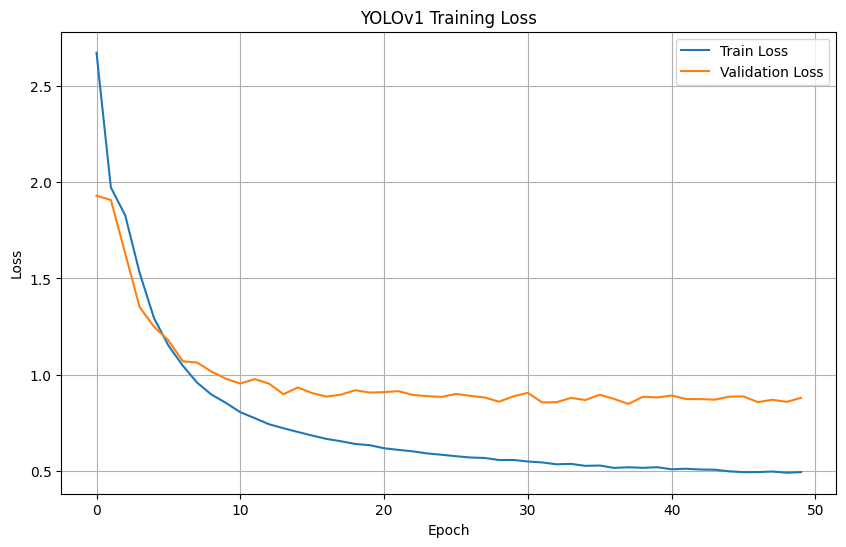

In [113]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("YOLOv1 Training Loss")

plt.legend()
plt.grid()

plt.show()

## 27. 실제 객체 탐지 결과 시각화

학습된 YOLOv1 모델이 실제 KITTI validation 이미지에서 객체를 어떻게 탐지하는지 확인합니다.

모델의 출력 `7 × 7 × 13`을 실제 Bounding Box로 변환한 뒤,
Confidence threshold와 NMS를 적용하고 원본 이미지 위에 결과를 표시합니다.

In [146]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from matplotlib.patches import Rectangle

# 학습 후 confidence가 0~1 범위가 되도록 모델 raw confidence에 sigmoid를 적용합니다.
CONF_THRESHOLD = 0.3
IOU_THRESHOLD = 0.50

# IoU 계산
def calculate_iou(box1, box2):
    """
    box format:
    [x1, y1, x2, y2]
    """

    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    inter_area = inter_w * inter_h

    area1 = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    area2 = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])

    union_area = area1 + area2 - inter_area

    if union_area <= 0:
        return 0.0

    return inter_area / union_area


# NMS

def nms(boxes, scores, iou_threshold=0.5):
    """같은 클래스의 중복 Bounding Box를 제거합니다."""

    if len(boxes) == 0:
        return []

    order = sorted(
        range(len(scores)),
        key=lambda i: scores[i],
        reverse=True
    )

    keep = []

    while order:
        current = order.pop(0)
        keep.append(current)

        remaining = []

        for idx in order:
            if calculate_iou(boxes[current], boxes[idx]) < iou_threshold:
                remaining.append(idx)

        order = remaining

    return keep


# YOLOv1 출력 → Detection

def decode_yolov1_output(
    prediction,
    image_width,
    image_height,
    conf_threshold=CONF_THRESHOLD,
    iou_threshold=0.5
):
    """
    prediction:
        [7, 7, 13] raw output

    학습 Loss와 동일하게
    box/conf/class에 필요한 activation을 적용합니다.
    """

    prediction = prediction.detach().cpu()
    detections = []

    for grid_y in range(S):
        for grid_x in range(S):

            # class logits -> class probability
            class_logits = prediction[grid_y, grid_x, 10:]
            class_probs = torch.softmax(class_logits, dim=0)
            class_id = torch.argmax(class_probs).item()
            class_score = class_probs[class_id].item()

            for box_idx in range(B):

                start = box_idx * 5

                # raw box
                x = torch.sigmoid(prediction[grid_y, grid_x, start]).item()
                y = torch.sigmoid(prediction[grid_y, grid_x, start + 1]).item()
                w = torch.sigmoid(prediction[grid_y, grid_x, start + 2]).item()
                h = torch.sigmoid(prediction[grid_y, grid_x, start + 3]).item()


                # raw confidence 
                confidence = torch.sigmoid(
                    prediction[grid_y, grid_x, start + 4]
                ).item()

                score = confidence * class_score

                if score < conf_threshold:
                    continue

                # Grid 내부 좌표 -> 전체 이미지 정규화 좌표
                x_center = (grid_x + x) / S
                y_center = (grid_y + y) / S

                # 정규화 좌표 -> 원본 이미지 픽셀 좌표
                x1 = (x_center - w / 2) * image_width
                y1 = (y_center - h / 2) * image_height
                x2 = (x_center + w / 2) * image_width
                y2 = (y_center + h / 2) * image_height

                # 이미지 범위 안으로 제한
                x1 = max(0, min(x1, image_width))
                y1 = max(0, min(y1, image_height))
                x2 = max(0, min(x2, image_width))
                y2 = max(0, min(y2, image_height))

                if x2 <= x1 or y2 <= y1:
                    continue

                detections.append({
                    "box": [x1, y1, x2, y2],
                    "score": score,
                    "class_id": class_id
                })

    # Class별 NMS
    final_detections = []

    for class_id in range(NUM_CLASSES):

        class_detections = [
            d for d in detections
            if d["class_id"] == class_id
        ]

        if not class_detections:
            continue

        boxes = [d["box"] for d in class_detections]
        scores = [d["score"] for d in class_detections]

        keep = nms(
            boxes,
            scores,
            iou_threshold
        )

        for idx in keep:
            final_detections.append(class_detections[idx])

    return final_detections


## 27-1. Validation 이미지에서 예측

Validation 이미지 중 일부를 무작위로 선택하여 학습된 YOLOv1 모델의 Detection 결과를 확인합니다.

각 이미지에 대해 모델 추론을 수행하고, 이후 시각화에 사용할 이미지와 Detection 결과를 `results`에 저장합니다.

In [154]:
import random

# Validation 이미지 여러 개 선택 
NUM_SAMPLES = 4
sample_image_paths = random.sample(val_images, min(NUM_SAMPLES, len(val_images)))

transform = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor()
])

# 추론 결과를 저장할 리스트
results = []
model.eval()

# 모델 추론 루프
for sample_image_path in sample_image_paths:
    image = Image.open(sample_image_path).convert("RGB")
    image_width, image_height = image.size

    # 모델 입력
    input_tensor = transform(image).unsqueeze(0).to(device)

    # 모델 예측
    with torch.no_grad():
        prediction = model(input_tensor)[0]

    # Detection
    detections = decode_yolov1_output(
        prediction,
        image_width,
        image_height,
        conf_threshold=CONF_THRESHOLD,
        iou_threshold=IOU_THRESHOLD
    )

    print(f"Image: {sample_image_path.name} | Detected objects: {len(detections)}")

    # 시각화를 위해 결과 저장
    results.append({
        "image": image,
        "detections": detections,
        "name": sample_image_path.name
    })

Image: 001180.png | Detected objects: 4
Image: 000524.png | Detected objects: 2
Image: 002152.png | Detected objects: 6
Image: 000988.png | Detected objects: 3


## 27-2. Detection 결과를 이미지에 표시
Validation 이미지에 Ground Truth와 YOLOv1의 Prediction 결과를 함께 표시합니다.

Ground Truth는 초록색 점선으로, Prediction은 빨간색 실선으로 나타내어 두 결과를 직접 비교할 수 있습니다.

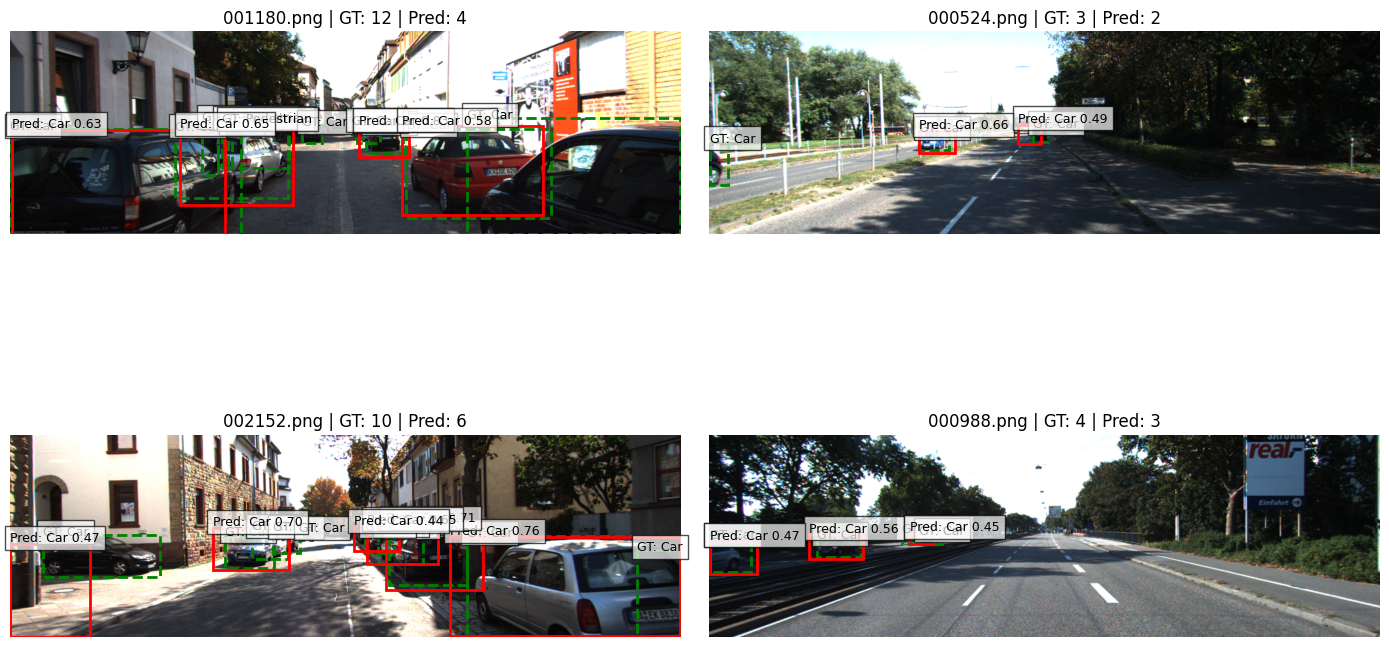

In [155]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

class_name_list = list(CLASS_NAMES.keys())

for idx, result in enumerate(results):
    ax = axes[idx]
    image = result["image"]
    detections = result["detections"]
    image_name = result["name"]

    # Ground Truth 읽기
    label_path = label_dir / f"{Path(image_name).stem}.txt"
    ground_truths = []

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()

            if len(parts) < 8:
                continue

            class_name = parts[0]

            if class_name not in CLASS_NAMES:
                continue

            ground_truths.append({
                "box": [
                    float(parts[4]),
                    float(parts[5]),
                    float(parts[6]),
                    float(parts[7])
                ],
                "class_name": class_name
            })

    ax.imshow(image)

    # Ground Truth
    for gt in ground_truths:
        x1, y1, x2, y2 = gt["box"]

        rect = Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2,
            linestyle="--",
            edgecolor="green"
        )
        ax.add_patch(rect)

        ax.text(
            x1,
            y1,
            f"GT: {gt['class_name']}",
            fontsize=9,
            bbox=dict(facecolor="white", alpha=0.7)
        )

    # Prediction
    for detection in detections:
        x1, y1, x2, y2 = detection["box"]
        score = detection["score"]
        class_id = detection["class_id"]
        class_name = class_name_list[class_id]

        rect = Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2,
            edgecolor="red"
        )
        ax.add_patch(rect)

        ax.text(
            x1,
            max(0, y1 - 5),
            f"Pred: {class_name} {score:.2f}",
            fontsize=9,
            bbox=dict(facecolor="white", alpha=0.7)
        )

    ax.set_title(
        f"{image_name} | GT: {len(ground_truths)} | Pred: {len(detections)}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()